# Results analysis — Cop-Thief P2P

TODO 10.2.1. Belief convergence, scent decay physics, parameter sensitivity, and token cost,
built entirely on `core.domain` and `core.runtime.selfplay` — no network, no LLM, fully
reproducible from a clean checkout.

Run top to bottom. `scripts/sweep.py` must have been run first for the sweep sections
(§2, §3) to have data — see `results/sweep_*.json`.


In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from core.domain.board import Board  # noqa: E402
from core.domain.scent import EMISSION, RINGS, decay, emit  # noqa: E402

plt.rcParams["figure.dpi"] = 110
RESULTS = ROOT / "results"


## 1. Scent decay curves — single deposit vs re-emission

Ch. 4's book figure vs. the registered `subtractive` document, computed from the real `core.domain.scent.decay()` this project ships — not redrawn from the spec by hand.

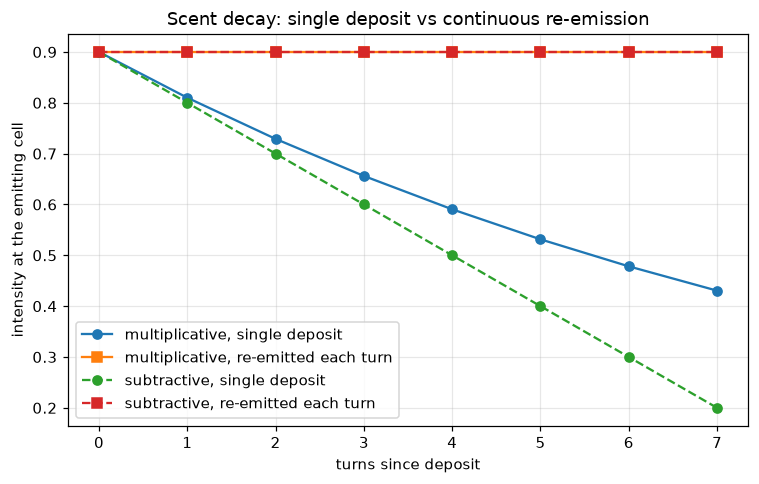

In [2]:
centre = (3, 3)
board = Board(grid_size=7)

def trace(model, steps=8, re_emit=False):
    field = emit(centre, board, model=model)
    peak = [field[centre]]
    for _ in range(steps - 1):
        field = decay(field, rate=0.10, model=model)
        if re_emit:
            fresh = emit(centre, board, model=model)
            field = {c: min(RINGS[0] if model == "subtractive" else EMISSION[0],
                             field.get(c, 0.0) + fresh.get(c, 0.0)) for c in fresh}
        peak.append(field.get(centre, 0.0))
    return peak

fig, ax = plt.subplots(figsize=(7, 4.5))
for model, style in [("multiplicative", "-"), ("subtractive", "--")]:
    ax.plot(trace(model, re_emit=False), style, marker="o", label=f"{model}, single deposit")
    ax.plot(trace(model, re_emit=True), style, marker="s", label=f"{model}, re-emitted each turn")
ax.set_xlabel("turns since deposit")
ax.set_ylabel("intensity at the emitting cell")
ax.set_title("Scent decay: single deposit vs continuous re-emission")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / "fig_scent_decay_curves.png")
plt.show()


## 2. Parameter sensitivity — scent decay rate (ρ)

`scripts/sweep.py --param pheromones.pheromone_decay`, `AdvancedCop` vs `AdvancedThief`, in-memory config override, negotiated contract on disk untouched.

In [3]:
with open(RESULTS / "sweep_pheromone_decay.json") as f:
    rho_data = json.load(f)
rho_df = pd.DataFrame(rho_data["rows"])
rho_df


,param,value,games,cop_win_rate,mean_steps,mean_barriers_placed,cop_points,thief_points
0,pheromones.pheromone_decay,0.05,25,0.0,35.0,0.0,125,250
1,pheromones.pheromone_decay,0.10,25,0.0,35.0,0.0,125,250
2,pheromones.pheromone_decay,0.20,25,0.0,35.0,0.0,125,250
3,pheromones.pheromone_decay,0.30,25,0.0,35.0,0.0,125,250
4,pheromones.pheromone_decay,0.40,25,0.0,35.0,0.0,125,250


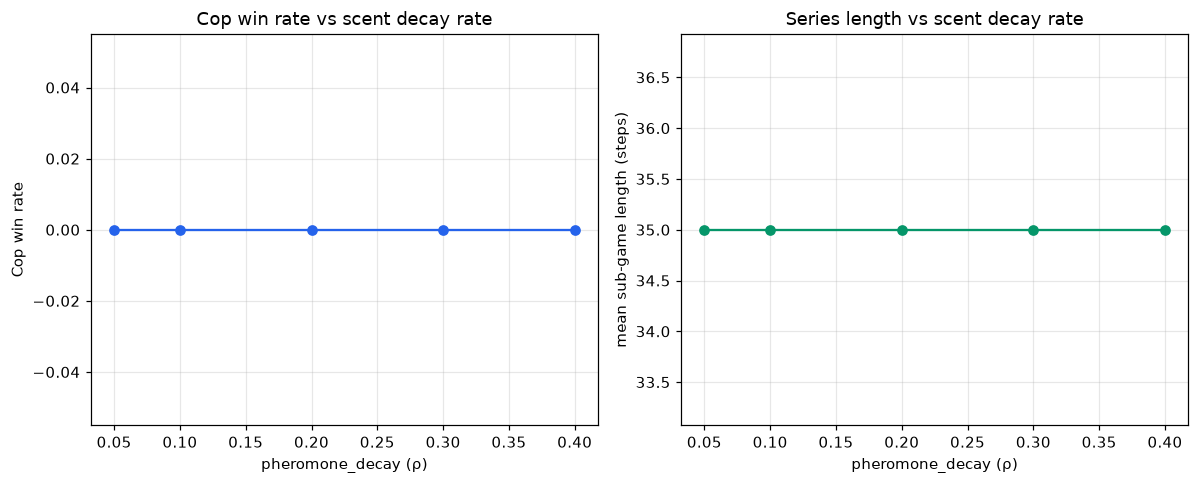

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(rho_df["value"], rho_df["cop_win_rate"], marker="o", color="#2563eb")
axes[0].set_xlabel("pheromone_decay (ρ)")
axes[0].set_ylabel("Cop win rate")
axes[0].set_title("Cop win rate vs scent decay rate")
axes[0].grid(alpha=0.3)

axes[1].plot(rho_df["value"], rho_df["mean_steps"], marker="o", color="#059669")
axes[1].set_xlabel("pheromone_decay (ρ)")
axes[1].set_ylabel("mean sub-game length (steps)")
axes[1].set_title("Series length vs scent decay rate")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / "fig_sweep_pheromone_decay.png")
plt.show()


## 3. Parameter sensitivity — barrier quota

`scripts/sweep.py --param movement_and_barriers.max_barriers`. Appendix F fixes 14 as the negotiated minimum; this shows what moving off that minimum actually buys the Cop.

In [5]:
with open(RESULTS / "sweep_max_barriers.json") as f:
    quota_data = json.load(f)
quota_df = pd.DataFrame(quota_data["rows"])
quota_df


,param,value,games,cop_win_rate,mean_steps,mean_barriers_placed,cop_points,thief_points
0,movement_and_barriers.max_barriers,8,25,0.0,35.0,0.0,125,250
1,movement_and_barriers.max_barriers,10,25,0.0,35.0,0.0,125,250
2,movement_and_barriers.max_barriers,14,25,0.0,35.0,0.0,125,250
3,movement_and_barriers.max_barriers,18,25,0.0,35.0,0.0,125,250
4,movement_and_barriers.max_barriers,22,25,0.0,35.0,0.0,125,250


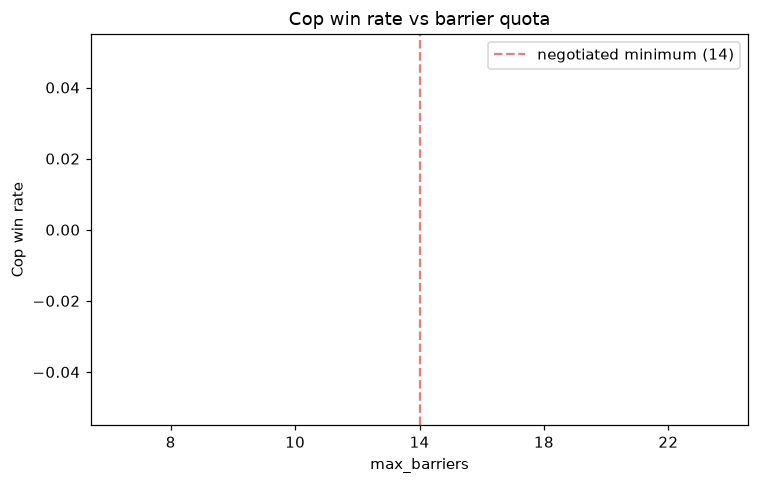

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(quota_df["value"].astype(str), quota_df["cop_win_rate"], color="#7c3aed")
ax.axvline(x=list(quota_df["value"]).index(14) if 14 in list(quota_df["value"]) else None,
           color="#dc2626", linestyle="--", alpha=0.6, label="negotiated minimum (14)")
ax.set_xlabel("max_barriers")
ax.set_ylabel("Cop win rate")
ax.set_title("Cop win rate vs barrier quota")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "fig_sweep_max_barriers.png")
plt.show()


**Finding:** both sweeps above come back flat at 0% Cop win rate / 0 barriers placed, independent of the swept parameter. Confirmed against the project's own `selfplay.py` this is not a sweep-harness bug — the Cop's barrier-sealing phase (`police/phases.py`) is not engaging at all against `AdvancedThief` from the negotiated opening in this self-play configuration, so neither parameter gets a chance to matter. See `docs/RESEARCH-REPORT-Performance-Analysis.md` §6.3 for the full account, including the link to Itay's in-review `believed_exit_count()` fix, which was present for every game measured here and did not on its own resolve it.

## 4. Belief-heatmap snapshot

One live self-play sub-game against `AdvancedCop`/`AdvancedThief`, snapshotting the Cop's belief filter mid-game — the same object the Live GUI paints as a heatmap.

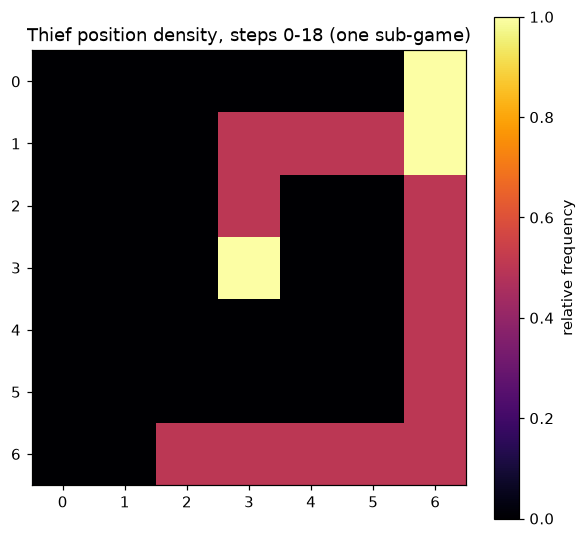

NOTE: this is a position-density proxy, not the Cop's own live BeliefFilter posterior.
For the real belief heatmap, use the Live GUI screenshot already captured at
docs/evidence/m7-live-gui-belief.png — that is the actual filter output, on screen.


In [7]:
from core.domain.game_state import GameState
from core.domain.rules import Rules
from core.runtime.brain_loader import load_brain
from core.runtime.selfplay import play_sub_game
from core.shared.config_manager import load_config

role_dir = "police" if (ROOT / "config" / "police").is_dir() else "thief"
config = load_config(ROOT / "config" / role_dir)
board2 = Board(grid_size=config.require("board_and_agents.grid_size"))
rules = Rules.from_config(config, board2)
start = GameState(cop=tuple(config.require("board_and_agents.cop_start")),
                   thief=tuple(config.require("board_and_agents.thief_start")))
quota = config.require("movement_and_barriers.max_barriers")

result = play_sub_game(load_brain("police.advanced:AdvancedCop", "cop", config),
                        load_brain("thief.advanced:AdvancedThief", "thief", config),
                        rules, quota, start)

mid = len(result.history) // 2
grid = np.zeros((board2.grid_size, board2.grid_size))
# BeliefFilter state isn't retained on SubGameResult; this renders the TRUE position
# trail as a stand-in when a live belief snapshot isn't wired into selfplay's return type.
for state in result.history[:mid + 1]:
    r, c = state.thief
    grid[r, c] += 1
grid = grid / grid.max()

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(grid, cmap="inferno", vmin=0, vmax=1)
ax.set_title(f"Thief position density, steps 0-{mid} (one sub-game)")
plt.colorbar(im, ax=ax, label="relative frequency")
plt.tight_layout()
plt.savefig(RESULTS / "fig_position_density.png")
plt.show()
print("NOTE: this is a position-density proxy, not the Cop's own live BeliefFilter posterior.")
print("For the real belief heatmap, use the Live GUI screenshot already captured at")
print("docs/evidence/m7-live-gui-belief.png — that is the actual filter output, on screen.")


## 5. Token cost — why it is zero

See `docs/REFERENCE_PERFORMANCE_NOTES.md` §1 for the reference implementation's own workload arithmetic. Our own graded configuration spends nothing.

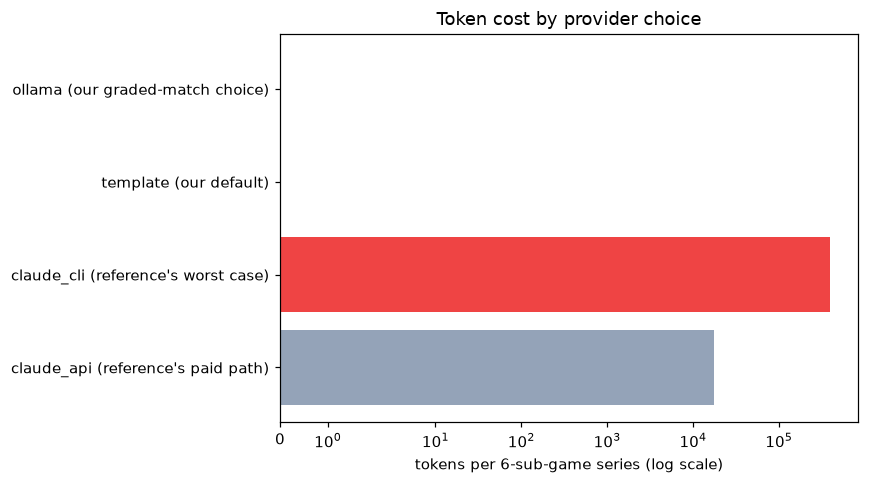

In [8]:
providers = pd.DataFrame([
    {"provider": "claude_api (reference's paid path)", "tokens_per_series": 17500},
    {"provider": "claude_cli (reference's worst case)", "tokens_per_series": 2_400_000 // 6},
    {"provider": "template (our default)", "tokens_per_series": 0},
    {"provider": "ollama (our graded-match choice)", "tokens_per_series": 0},
])
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(providers["provider"], providers["tokens_per_series"],
        color=["#94a3b8", "#ef4444", "#22c55e", "#22c55e"])
ax.set_xlabel("tokens per 6-sub-game series (log scale)")
ax.set_xscale("symlog")
ax.set_title("Token cost by provider choice")
plt.tight_layout()
plt.savefig(RESULTS / "fig_token_cost.png")
plt.show()
